# Clustering conclusiones finales

Esta libreta utiliza el dataset final integrado con la clasificación de consumo y comportamiento por hogar. El objetivo es convertir las variables categóricas a una representación numérica adecuada y evaluar una clusterización final con **K-Means** y **DBSCAN**.

El enfoque busca responder una pregunta de cierre: si ya tenemos segmentos por consumo, horario, patrón semanal y tipo de consumo, ¿qué agrupaciones finales aparecen al combinar esas dimensiones?


# 1. Configuración general y rutas

Se definen las rutas de entrada y salida. Todos los artefactos de esta libreta se guardan en una carpeta independiente para mantener trazabilidad.


In [30]:
from pathlib import Path
import os
import warnings

PROJECT_DIR = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(PROJECT_DIR / ".cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
INPUT_PATH = PROJECT_DIR / "output" / "smart_meters_clustering_consumo" / "tables" / "df_18_consumo_comportamiento_merge.csv"
OUTPUT_DIR = PROJECT_DIR / "output" / "clustering_conclusiones_finales"
TABLES_DIR = OUTPUT_DIR / "tables"
IMAGES_DIR = OUTPUT_DIR / "images"

for directory in [OUTPUT_DIR, TABLES_DIR, IMAGES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset de entrada:", INPUT_PATH)
print("Existe dataset:", INPUT_PATH.exists())
print("Tablas:", TABLES_DIR)
print("Gráficas:", IMAGES_DIR)


Dataset de entrada: /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/smart_meters_clustering_consumo/tables/df_18_consumo_comportamiento_merge.csv
Existe dataset: True
Tablas: /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/clustering_conclusiones_finales/tables
Gráficas: /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/clustering_conclusiones_finales/images


# 2. Carga del dataset final

El dataset contiene una fila por casa, el cluster de consumo obtenido en la libreta de consumo y las tres clasificaciones de comportamiento provenientes de la libreta de comportamiento final.


In [31]:
df_base = pd.read_csv(INPUT_PATH)

columnas_esperadas = ["casa", "cluster_consumo", "horario_consumo", "semanal", "tipo_consumo"]
faltantes = [col for col in columnas_esperadas if col not in df_base.columns]
if faltantes:
    raise ValueError(f"Faltan columnas esperadas: {faltantes}")

df_01_resumen_dataset = pd.DataFrame({
    "metrica": [
        "filas",
        "columnas",
        "casas_unicas",
        "duplicados_casa",
        "nulos_totales"
    ],
    "valor": [
        len(df_base),
        df_base.shape[1],
        df_base["casa"].nunique(),
        df_base.duplicated("casa").sum(),
        int(df_base.isna().sum().sum())
    ]
})

df_01_resumen_dataset.to_csv(TABLES_DIR / "df_01_resumen_dataset.csv", index=False)
display(df_01_resumen_dataset)
display(df_base.head())


,metrica,valor
0,filas,5384
1,columnas,5
2,casas_unicas,5384
3,duplicados_casa,0
4,nulos_totales,0


,casa,cluster_consumo,horario_consumo,semanal,tipo_consumo
0,MAC000002,0,consumo_noche_variable,consumo_fin_semana_variable,picos_bajos_variabilidad_baja
1,MAC000003,2,consumo_madrugada_variable,consumo_fin_semana_estable,picos_moderados_variabilidad_media
2,MAC000004,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media
3,MAC000005,1,consumo_noche_variable,consumo_fin_semana_estable,picos_bajos_variabilidad_baja
4,MAC000006,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media


# 3. Revisión de categorías

Antes de codificar, se revisa cuántas categorías tiene cada variable y su distribución. Esto ayuda a detectar categorías dominantes o segmentos muy pequeños que podrían afectar el clustering final.


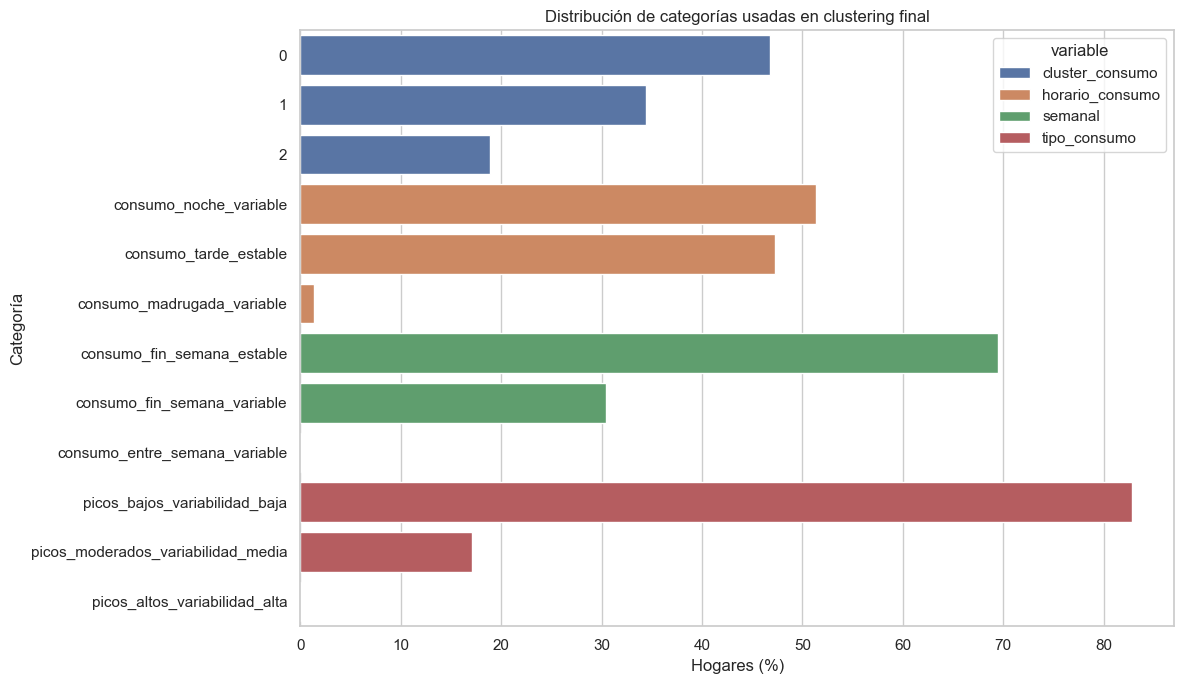

,variable,categoria,hogares,pct_hogares
0,cluster_consumo,0,2519,46.7868
1,cluster_consumo,1,1851,34.3796
2,cluster_consumo,2,1014,18.8336
3,horario_consumo,consumo_noche_variable,2765,51.3559
4,horario_consumo,consumo_tarde_estable,2547,47.3068
5,horario_consumo,consumo_madrugada_variable,72,1.3373
6,semanal,consumo_fin_semana_estable,3743,69.5208
7,semanal,consumo_fin_semana_variable,1639,30.4421
8,semanal,consumo_entre_semana_variable,2,0.0371
9,tipo_consumo,picos_bajos_variabilidad_baja,4462,82.8752


In [32]:
variables_segmentacion = ["cluster_consumo", "horario_consumo", "semanal", "tipo_consumo"]

registros = []
for col in variables_segmentacion:
    conteos = df_base[col].value_counts(dropna=False)
    for categoria, hogares in conteos.items():
        registros.append({
            "variable": col,
            "categoria": str(categoria),
            "hogares": int(hogares),
            "pct_hogares": hogares / len(df_base) * 100
        })

df_02_distribucion_categorias = pd.DataFrame(registros)
df_02_distribucion_categorias.to_csv(TABLES_DIR / "df_02_distribucion_categorias.csv", index=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_02_distribucion_categorias, x="pct_hogares", y="categoria", hue="variable")
plt.title("Distribución de categorías usadas en clustering final")
plt.xlabel("Hogares (%)")
plt.ylabel("Categoría")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "distribucion_categorias_base.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_02_distribucion_categorias)


# 4. Transformación de variables categóricas a numéricas

Para evitar imponer un orden artificial entre categorías, se usa codificación **one-hot**. Esto convierte cada categoría en una columna binaria. El identificador de casa no entra al modelo; sólo se conserva para unir resultados.


In [33]:
df_modelo = df_base.copy()
df_modelo["cluster_consumo"] = df_modelo["cluster_consumo"].astype(str).radd("cluster_")

variables_categoricas = ["cluster_consumo", "horario_consumo", "semanal", "tipo_consumo"]
encoded_blocks = []
diccionario_codificacion = []

for col in variables_categoricas:
    dummies = pd.get_dummies(df_modelo[col], prefix=col, dtype=float)
    encoded_blocks.append(dummies)
    for dummy_col in dummies.columns:
        diccionario_codificacion.append({
            "variable_original": col,
            "categoria": dummy_col.replace(f"{col}_", ""),
            "variable_codificada": dummy_col
        })

X_encoded_df = pd.concat(encoded_blocks, axis=1)
X_encoded = X_encoded_df.values

df_03_diccionario_codificacion = pd.DataFrame(diccionario_codificacion)
df_03_matriz_modelo = pd.concat([df_base[["casa"]], X_encoded_df], axis=1)

df_03_diccionario_codificacion.to_csv(TABLES_DIR / "df_03_diccionario_codificacion.csv", index=False)
df_03_matriz_modelo.to_csv(TABLES_DIR / "df_03_matriz_modelo_one_hot.csv", index=False)

print("Shape matriz one-hot:", X_encoded_df.shape)
display(df_03_diccionario_codificacion)
display(df_03_matriz_modelo.head())


Shape matriz one-hot: (5384, 12)


,variable_original,categoria,variable_codificada
0,cluster_consumo,cluster_0,cluster_consumo_cluster_0
1,cluster_consumo,cluster_1,cluster_consumo_cluster_1
2,cluster_consumo,cluster_2,cluster_consumo_cluster_2
3,horario_consumo,consumo_madrugada_variable,horario_consumo_consumo_madrugada_variable
4,horario_consumo,consumo_noche_variable,horario_consumo_consumo_noche_variable
5,horario_consumo,consumo_tarde_estable,horario_consumo_consumo_tarde_estable
6,semanal,consumo_entre_semana_variable,semanal_consumo_entre_semana_variable
7,semanal,consumo_fin_semana_estable,semanal_consumo_fin_semana_estable
8,semanal,consumo_fin_semana_variable,semanal_consumo_fin_semana_variable
9,tipo_consumo,picos_altos_variabilidad_alta,tipo_consumo_picos_altos_variabilidad_alta


,casa,cluster_consumo_cluster_0,cluster_consumo_cluster_1,cluster_consumo_cluster_2,horario_consumo_consumo_madrugada_variable,horario_consumo_consumo_noche_variable,horario_consumo_consumo_tarde_estable,semanal_consumo_entre_semana_variable,semanal_consumo_fin_semana_estable,semanal_consumo_fin_semana_variable,tipo_consumo_picos_altos_variabilidad_alta,tipo_consumo_picos_bajos_variabilidad_baja,tipo_consumo_picos_moderados_variabilidad_media
0,MAC000002,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
1,MAC000003,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
2,MAC000004,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
3,MAC000005,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
4,MAC000006,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000


# 5. Visualización inicial con PCA

PCA se usa únicamente como herramienta visual para proyectar la matriz one-hot en dos dimensiones. No cambia la matriz con la que se entrenan K-Means y DBSCAN.


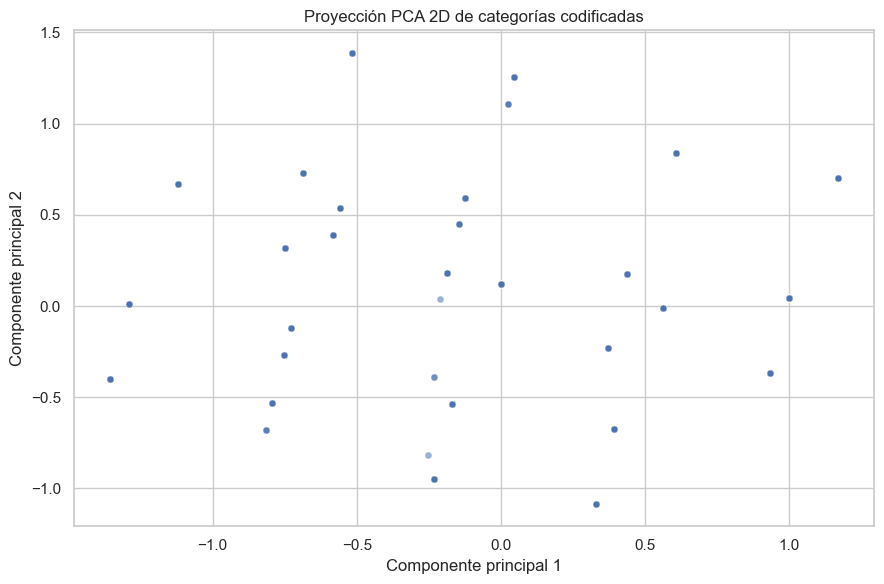

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.3225,0.3225
1,PC2,0.2223,0.5448


In [34]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_encoded)

df_04_pca = pd.DataFrame({
    "casa": df_base["casa"],
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1]
})

df_04_varianza_pca = pd.DataFrame({
    "componente": ["PC1", "PC2"],
    "varianza_explicada": pca_2d.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca_2d.explained_variance_ratio_)
})

df_04_pca.to_csv(TABLES_DIR / "df_04_pca_visualizacion.csv", index=False)
df_04_varianza_pca.to_csv(TABLES_DIR / "df_04_varianza_pca_visualizacion.csv", index=False)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_04_pca, x="PC1", y="PC2", s=25, alpha=0.55)
plt.title("Proyección PCA 2D de categorías codificadas")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "pca_base_categorias_codificadas.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_04_varianza_pca)


# 6. Funciones de evaluación

Se evalúan métricas internas estándar. En DBSCAN se agrega el porcentaje de ruido, porque un resultado puede verse bien técnicamente pero ser poco útil si deja muchos hogares sin clasificar.


In [35]:
def evaluar_labels(X_eval, labels, modelo, configuracion):
    labels = np.asarray(labels)
    mascara_valida = labels != -1
    labels_validos = labels[mascara_valida]
    X_valid = X_eval[mascara_valida]
    n_clusters = len(set(labels_validos))
    ruido_pct = float((~mascara_valida).mean() * 100)

    if len(labels_validos) > 0:
        distribucion = pd.Series(labels_validos).value_counts(normalize=True) * 100
        cluster_mayor = distribucion.max()
        cluster_menor = distribucion.min()
    else:
        cluster_mayor = np.nan
        cluster_menor = np.nan

    if n_clusters >= 2 and X_valid.shape[0] > n_clusters:
        silhouette = silhouette_score(X_valid, labels_validos)
        davies = davies_bouldin_score(X_valid, labels_validos)
        calinski = calinski_harabasz_score(X_valid, labels_validos)
    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    return {
        "modelo": modelo,
        "configuracion": configuracion,
        "n_clusters": n_clusters,
        "ruido_pct": ruido_pct,
        "cluster_mayor_pct_sin_ruido": cluster_mayor,
        "cluster_menor_pct_sin_ruido": cluster_menor,
        "Silhouette": silhouette,
        "Davies_Bouldin": davies,
        "Calinski_Harabasz": calinski,
    }


# 7. Evaluación de K-Means

Se prueba K-Means con distintos valores de K. Además de las métricas, se revisa el tamaño relativo del cluster mayor y menor para detectar segmentaciones demasiado concentradas o fragmentadas.


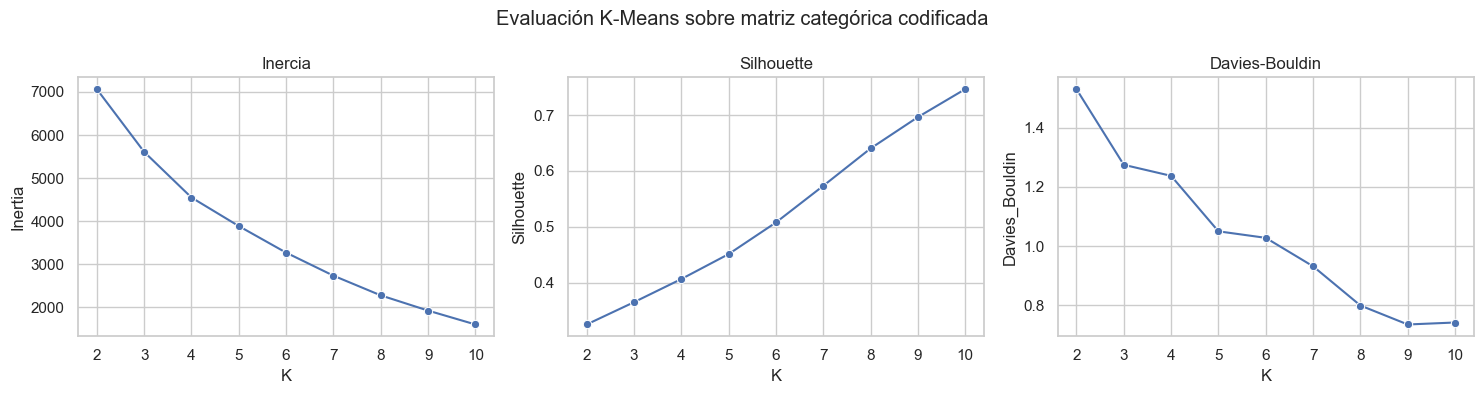

,modelo,configuracion,K,Inertia,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,KMeans,K=2,2,"7,064.8955",2,0.0000,51.3559,48.6441,0.3251,1.5310,"2,196.3612"
1,KMeans,K=3,3,"5,608.4825",3,0.0000,37.2585,30.4421,0.3650,1.2748,"2,081.7697"
2,KMeans,K=4,4,"4,549.6296",4,0.0000,30.9435,16.6790,0.4065,1.2374,"2,127.8967"
3,KMeans,K=5,5,"3,886.8044",5,0.0000,27.6560,15.1374,0.4511,1.0497,"2,097.0546"
4,KMeans,K=6,6,"3,270.5523",6,0.0000,24.7028,9.7697,0.5078,1.0277,"2,196.0516"
5,KMeans,K=7,7,"2,736.0078",7,0.0000,19.0750,9.7697,0.5734,0.9314,"2,362.2664"
6,KMeans,K=8,8,"2,279.2281",8,0.0000,19.0750,8.5810,0.6403,0.7987,"2,584.0523"
7,KMeans,K=9,9,"1,925.9460",9,0.0000,15.1374,5.7207,0.6965,0.7345,"2,798.5426"
8,KMeans,K=10,10,"1,603.8430",10,0.0000,15.1374,5.7764,0.7466,0.7412,"3,106.5450"


In [36]:
resultados_kmeans = []
modelos_kmeans = {}
labels_kmeans = {}

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30, max_iter=300)
    labels = modelo.fit_predict(X_encoded)
    metrica = evaluar_labels(X_encoded, labels, "KMeans", f"K={k}")
    metrica["K"] = k
    metrica["Inertia"] = modelo.inertia_
    resultados_kmeans.append(metrica)
    modelos_kmeans[k] = modelo
    labels_kmeans[k] = labels

df_05_kmeans_evaluacion = pd.DataFrame(resultados_kmeans)
df_05_kmeans_evaluacion = df_05_kmeans_evaluacion[[
    "modelo", "configuracion", "K", "Inertia", "n_clusters", "ruido_pct",
    "cluster_mayor_pct_sin_ruido", "cluster_menor_pct_sin_ruido",
    "Silhouette", "Davies_Bouldin", "Calinski_Harabasz"
]]
df_05_kmeans_evaluacion.to_csv(TABLES_DIR / "df_05_kmeans_evaluacion.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.lineplot(data=df_05_kmeans_evaluacion, x="K", y="Inertia", marker="o", ax=axes[0])
axes[0].set_title("Inercia")
sns.lineplot(data=df_05_kmeans_evaluacion, x="K", y="Silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette")
sns.lineplot(data=df_05_kmeans_evaluacion, x="K", y="Davies_Bouldin", marker="o", ax=axes[2])
axes[2].set_title("Davies-Bouldin")
fig.suptitle("Evaluación K-Means sobre matriz categórica codificada")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "kmeans_metricas_conclusiones_finales.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_05_kmeans_evaluacion)


# 8. Evaluación de DBSCAN

DBSCAN se prueba con una malla de valores de `eps` y `min_samples`. En una matriz one-hot, `eps` controla qué tan parecidos deben ser dos hogares en sus categorías para quedar conectados.


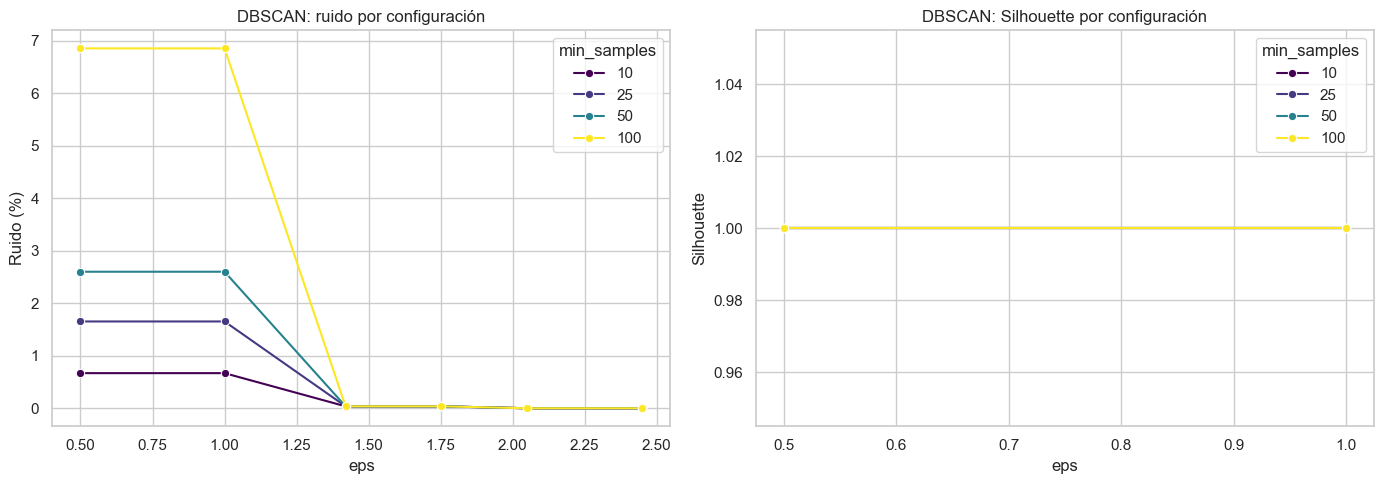

,modelo,configuracion,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,eps,min_samples
0,DBSCAN,"eps=0.5, min_samples=10",23,0.6686,14.7719,0.1870,1.0000,0.0000,1.0000,0.5000,10
1,DBSCAN,"eps=1.0, min_samples=10",23,0.6686,14.7719,0.1870,1.0000,0.0000,1.0000,1.0000,10
2,DBSCAN,"eps=0.5, min_samples=25",20,1.6530,14.9197,0.4721,1.0000,0.0000,1.0000,0.5000,25
3,DBSCAN,"eps=1.0, min_samples=25",20,1.6530,14.9197,0.4721,1.0000,0.0000,1.0000,1.0000,25
4,DBSCAN,"eps=0.5, min_samples=50",18,2.6003,15.0648,0.9535,1.0000,0.0000,1.0000,0.5000,50
5,DBSCAN,"eps=1.0, min_samples=50",18,2.6003,15.0648,0.9535,1.0000,0.0000,1.0000,1.0000,50
6,DBSCAN,"eps=0.5, min_samples=100",14,6.8536,15.7527,2.3330,1.0000,0.0000,1.0000,0.5000,100
7,DBSCAN,"eps=1.0, min_samples=100",14,6.8536,15.7527,2.3330,1.0000,0.0000,1.0000,1.0000,100
8,DBSCAN,"eps=2.05, min_samples=10",1,0.0000,100.0000,100.0000,NaN,NaN,NaN,2.0500,10
9,DBSCAN,"eps=2.05, min_samples=25",1,0.0000,100.0000,100.0000,NaN,NaN,NaN,2.0500,25


In [37]:
eps_grid = [0.50, 1.00, 1.42, 1.75, 2.05, 2.45]
min_samples_grid = [10, 25, 50, 100]
resultados_dbscan = []
labels_dbscan = {}

for eps in eps_grid:
    for min_samples in min_samples_grid:
        modelo = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
        labels = modelo.fit_predict(X_encoded)
        config = f"eps={eps}, min_samples={min_samples}"
        metrica = evaluar_labels(X_encoded, labels, "DBSCAN", config)
        metrica["eps"] = eps
        metrica["min_samples"] = min_samples
        resultados_dbscan.append(metrica)
        labels_dbscan[(eps, min_samples)] = labels

df_06_dbscan_evaluacion = pd.DataFrame(resultados_dbscan)
df_06_dbscan_evaluacion = df_06_dbscan_evaluacion.sort_values(
    ["Silhouette", "ruido_pct", "Davies_Bouldin"],
    ascending=[False, True, True],
    na_position="last"
).reset_index(drop=True)
df_06_dbscan_evaluacion.to_csv(TABLES_DIR / "df_06_dbscan_evaluacion.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_06_dbscan_evaluacion, x="eps", y="ruido_pct", hue="min_samples", marker="o", ax=axes[0], palette="viridis")
axes[0].set_title("DBSCAN: ruido por configuración")
axes[0].set_ylabel("Ruido (%)")
sns.lineplot(data=df_06_dbscan_evaluacion, x="eps", y="Silhouette", hue="min_samples", marker="o", ax=axes[1], palette="viridis")
axes[1].set_title("DBSCAN: Silhouette por configuración")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "dbscan_metricas_conclusiones_finales.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_06_dbscan_evaluacion.head(15))


# 9. Comparación entre modelos

Se comparan los mejores candidatos de K-Means y DBSCAN. Para la selección final se privilegia una solución interpretable, con al menos dos clusters, bajo ruido y sin concentración extrema en un solo grupo.


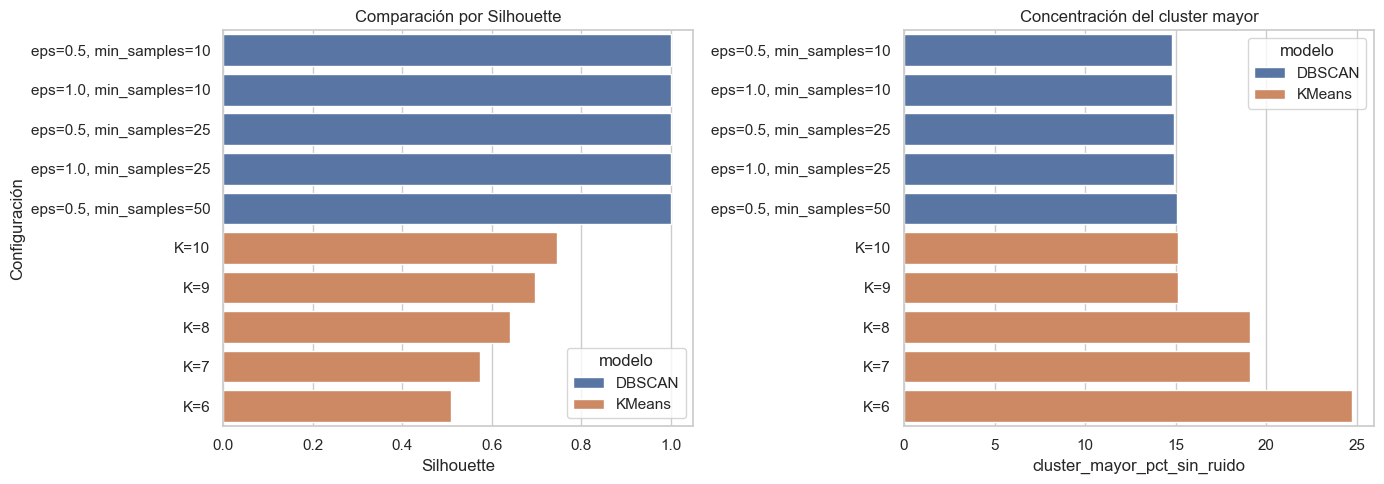

,modelo,configuracion,K,Inertia,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,eps,min_samples
0,DBSCAN,"eps=0.5, min_samples=10",NaN,NaN,23,0.6686,14.7719,0.1870,1.0000,0.0000,1.0000,0.5000,10.0000
1,DBSCAN,"eps=1.0, min_samples=10",NaN,NaN,23,0.6686,14.7719,0.1870,1.0000,0.0000,1.0000,1.0000,10.0000
2,DBSCAN,"eps=0.5, min_samples=25",NaN,NaN,20,1.6530,14.9197,0.4721,1.0000,0.0000,1.0000,0.5000,25.0000
3,DBSCAN,"eps=1.0, min_samples=25",NaN,NaN,20,1.6530,14.9197,0.4721,1.0000,0.0000,1.0000,1.0000,25.0000
4,DBSCAN,"eps=0.5, min_samples=50",NaN,NaN,18,2.6003,15.0648,0.9535,1.0000,0.0000,1.0000,0.5000,50.0000
5,KMeans,K=10,10.0000,"1,603.8430",10,0.0000,15.1374,5.7764,0.7466,0.7412,"3,106.5450",NaN,NaN
6,KMeans,K=9,9.0000,"1,925.9460",9,0.0000,15.1374,5.7207,0.6965,0.7345,"2,798.5426",NaN,NaN
7,KMeans,K=8,8.0000,"2,279.2281",8,0.0000,19.0750,8.5810,0.6403,0.7987,"2,584.0523",NaN,NaN
8,KMeans,K=7,7.0000,"2,736.0078",7,0.0000,19.0750,9.7697,0.5734,0.9314,"2,362.2664",NaN,NaN
9,KMeans,K=6,6.0000,"3,270.5523",6,0.0000,24.7028,9.7697,0.5078,1.0277,"2,196.0516",NaN,NaN


In [38]:
top_kmeans = df_05_kmeans_evaluacion.sort_values("Silhouette", ascending=False).head(5)

dbscan_validos = df_06_dbscan_evaluacion[
    (df_06_dbscan_evaluacion["n_clusters"] >= 2) &
    (df_06_dbscan_evaluacion["ruido_pct"] <= 30)
].copy()
if dbscan_validos.empty:
    dbscan_validos = df_06_dbscan_evaluacion[df_06_dbscan_evaluacion["n_clusters"] >= 2].copy()

top_dbscan = dbscan_validos.sort_values(["Silhouette", "ruido_pct"], ascending=[False, True]).head(5)

df_07_comparacion_modelos = pd.concat([top_kmeans, top_dbscan], ignore_index=True, sort=False)
df_07_comparacion_modelos = df_07_comparacion_modelos.sort_values("Silhouette", ascending=False, na_position="last").reset_index(drop=True)
df_07_comparacion_modelos.to_csv(TABLES_DIR / "df_07_comparacion_modelos.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_07_comparacion_modelos, y="configuracion", x="Silhouette", hue="modelo", ax=axes[0])
axes[0].set_title("Comparación por Silhouette")
axes[0].set_ylabel("Configuración")
sns.barplot(data=df_07_comparacion_modelos, y="configuracion", x="cluster_mayor_pct_sin_ruido", hue="modelo", ax=axes[1])
axes[1].set_title("Concentración del cluster mayor")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "comparacion_kmeans_dbscan_conclusiones_finales.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_07_comparacion_modelos)


# 10. Selección de configuración candidata y asignación final

Se genera una tabla de asignación para el mejor candidato de K-Means y el mejor candidato de DBSCAN. Esto permite revisar ambas alternativas antes de tomar una decisión de negocio definitiva.


In [39]:
# Selección candidata con criterio técnico y de negocio.
# No se toma automáticamente el K con mayor Silhouette si implica demasiados grupos.
kmeans_candidatos_operativos = df_05_kmeans_evaluacion[
    (df_05_kmeans_evaluacion["K"].between(3, 7)) &
    (df_05_kmeans_evaluacion["cluster_menor_pct_sin_ruido"] >= 5)
].copy()

if kmeans_candidatos_operativos.empty:
    kmeans_candidatos_operativos = df_05_kmeans_evaluacion.copy()

kmeans_candidato = kmeans_candidatos_operativos.sort_values(
    ["Silhouette", "cluster_menor_pct_sin_ruido"], ascending=[False, False]
).iloc[0]
K_FINAL_CANDIDATO = int(kmeans_candidato["K"])
labels_kmeans_final = labels_kmeans[K_FINAL_CANDIDATO]

# Para DBSCAN se prefieren soluciones con ruido bajo y sin demasiados microclusters.
dbscan_candidatos_operativos = df_06_dbscan_evaluacion[
    (df_06_dbscan_evaluacion["n_clusters"].between(2, 15)) &
    (df_06_dbscan_evaluacion["ruido_pct"] <= 10) &
    (df_06_dbscan_evaluacion["cluster_menor_pct_sin_ruido"] >= 1)
].copy()

if dbscan_candidatos_operativos.empty:
    dbscan_candidatos_operativos = df_06_dbscan_evaluacion[df_06_dbscan_evaluacion["n_clusters"] >= 2].copy()

if dbscan_candidatos_operativos.empty:
    dbscan_candidato = df_06_dbscan_evaluacion.iloc[0]
else:
    dbscan_candidato = dbscan_candidatos_operativos.sort_values(
        ["Silhouette", "n_clusters", "ruido_pct"], ascending=[False, True, True]
    ).iloc[0]

EPS_FINAL = float(dbscan_candidato["eps"])
MIN_SAMPLES_FINAL = int(dbscan_candidato["min_samples"])
labels_dbscan_final = labels_dbscan[(EPS_FINAL, MIN_SAMPLES_FINAL)]

df_08_clusterizacion_final = df_base.copy()
df_08_clusterizacion_final["cluster_kmeans_final"] = labels_kmeans_final
df_08_clusterizacion_final["cluster_dbscan_final"] = labels_dbscan_final

df_08_configuracion_final = pd.DataFrame([
    {
        "modelo": "KMeans",
        "configuracion": f"K={K_FINAL_CANDIDATO}",
        "criterio_seleccion": "mejor Silhouette dentro de K operativo 3-7 y cluster menor >= 5%",
        "clusters_generados": len(set(labels_kmeans_final)),
        "ruido_pct": 0.0
    },
    {
        "modelo": "DBSCAN",
        "configuracion": f"eps={EPS_FINAL}, min_samples={MIN_SAMPLES_FINAL}",
        "criterio_seleccion": "ruido <= 10%, 2-15 clusters y cluster menor >= 1% cuando fue posible",
        "clusters_generados": len(set(labels_dbscan_final) - {-1}),
        "ruido_pct": (labels_dbscan_final == -1).mean() * 100
    }
])

df_08_clusterizacion_final.to_csv(TABLES_DIR / "df_08_clusterizacion_final_kmeans_dbscan.csv", index=False)
df_08_configuracion_final.to_csv(TABLES_DIR / "df_08_configuracion_final.csv", index=False)

display(df_08_configuracion_final)
display(df_08_clusterizacion_final.head())

,modelo,configuracion,criterio_seleccion,clusters_generados,ruido_pct
0,KMeans,K=7,mejor Silhouette dentro de K operativo 3-7 y c...,7,0.0000
1,DBSCAN,"eps=0.5, min_samples=100","ruido <= 10%, 2-15 clusters y cluster menor >=...",14,6.8536


,casa,cluster_consumo,horario_consumo,semanal,tipo_consumo,cluster_kmeans_final,cluster_dbscan_final
0,MAC000002,0,consumo_noche_variable,consumo_fin_semana_variable,picos_bajos_variabilidad_baja,1,0
1,MAC000003,2,consumo_madrugada_variable,consumo_fin_semana_estable,picos_moderados_variabilidad_media,5,-1
2,MAC000004,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media,5,1
3,MAC000005,1,consumo_noche_variable,consumo_fin_semana_estable,picos_bajos_variabilidad_baja,2,2
4,MAC000006,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media,5,1


# 11. Visualización de clusters finales

Se proyectan las asignaciones finales sobre PCA 2D para observar cómo se separan los grupos de K-Means y DBSCAN sobre las combinaciones categóricas codificadas.


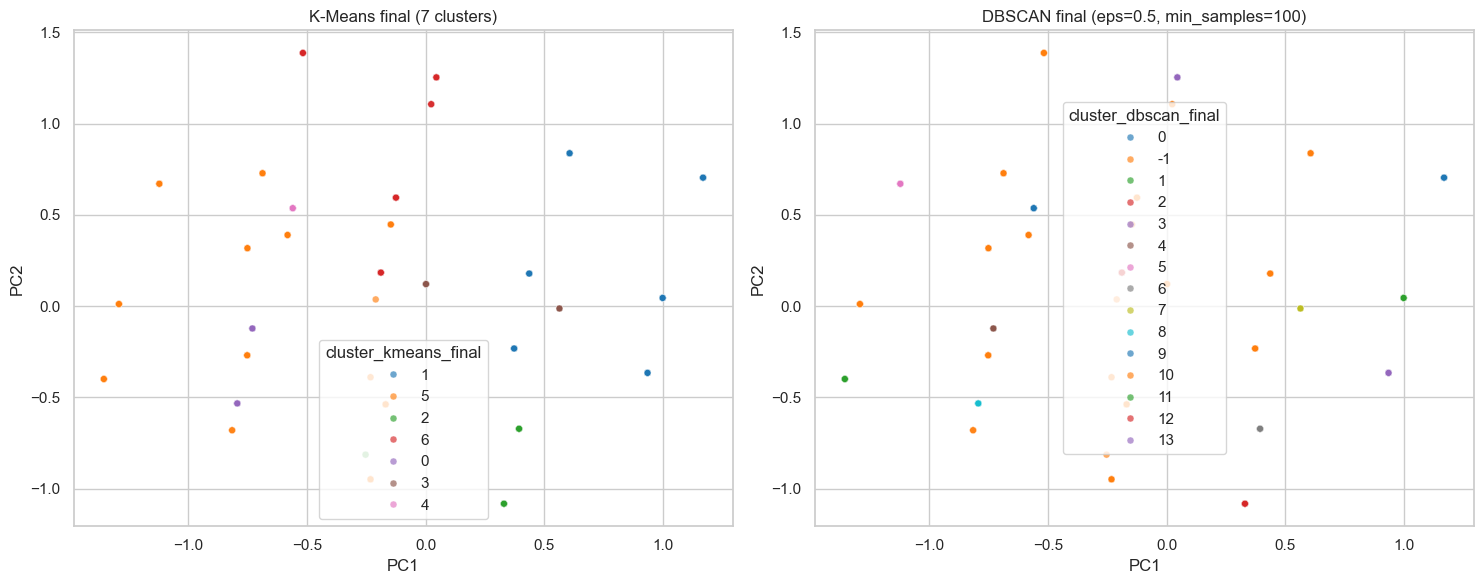

In [40]:
df_plot_final = df_04_pca.copy()
df_plot_final["cluster_kmeans_final"] = labels_kmeans_final.astype(str)
df_plot_final["cluster_dbscan_final"] = labels_dbscan_final.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=df_plot_final, x="PC1", y="PC2", hue="cluster_kmeans_final", palette="tab10", s=25, alpha=0.65, ax=axes[0])
axes[0].set_title(f"K-Means final ({K_FINAL_CANDIDATO} clusters)")
sns.scatterplot(data=df_plot_final, x="PC1", y="PC2", hue="cluster_dbscan_final", palette="tab10", s=25, alpha=0.65, ax=axes[1])
axes[1].set_title(f"DBSCAN final (eps={EPS_FINAL}, min_samples={MIN_SAMPLES_FINAL})")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "clusters_finales_pca_kmeans_dbscan.png", dpi=160, bbox_inches="tight")
plt.show()


# 12. Entrenamiento final K-Means K = 7 con variables de negocio

A partir de la evaluación previa, se entrena explícitamente el modelo **K-Means con K = 7**, que fue el candidato operativo con mejor desempeño dentro del rango interpretable. Después se asigna el cluster final a cada casa y se incorporan las variables de negocio `Acorn_grouped` y `stdorToU` para facilitar la interpretación comercial de los segmentos.


In [41]:
K_FINAL_NEGOCIO = 7

modelo_kmeans_k7 = KMeans(n_clusters=K_FINAL_NEGOCIO, random_state=RANDOM_STATE, n_init=30, max_iter=300)
labels_kmeans_k7 = modelo_kmeans_k7.fit_predict(X_encoded)

metricas_kmeans_k7 = evaluar_labels(X_encoded, labels_kmeans_k7, "KMeans", f"K={K_FINAL_NEGOCIO}")
metricas_kmeans_k7["Inertia"] = modelo_kmeans_k7.inertia_

df_11_metricas_kmeans_k7 = pd.DataFrame([metricas_kmeans_k7])
df_11_metricas_kmeans_k7.to_csv(TABLES_DIR / "df_11_metricas_kmeans_k7.csv", index=False)

df_11_kmeans_k7_por_casa = df_base.copy()
df_11_kmeans_k7_por_casa["cluster_kmeans_k7"] = labels_kmeans_k7.astype(int)

perfil_hogar_path = PROJECT_DIR / "data" / "smart_meters_hogar_perfil.csv"
if not perfil_hogar_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo de perfil de hogar: {perfil_hogar_path}")

perfil_hogar_negocio = pd.read_csv(perfil_hogar_path)[["LCLid", "Acorn_grouped", "stdorToU"]].rename(columns={"LCLid": "casa"})

df_11_kmeans_k7_por_casa = df_11_kmeans_k7_por_casa.merge(
    perfil_hogar_negocio,
    on="casa",
    how="left",
    validate="one_to_one"
)

columnas_finales_k7 = [
    "casa",
    "cluster_kmeans_k7",
    "cluster_consumo",
    "horario_consumo",
    "semanal",
    "tipo_consumo",
    "Acorn_grouped",
    "stdorToU"
]
df_11_kmeans_k7_por_casa = df_11_kmeans_k7_por_casa[columnas_finales_k7]

df_11_validacion_kmeans_k7 = pd.DataFrame({
    "metrica": [
        "casas_clusterizadas",
        "clusters_generados",
        "casas_sin_Acorn_grouped",
        "casas_sin_stdorToU",
        "cluster_mayor_pct",
        "cluster_menor_pct"
    ],
    "valor": [
        len(df_11_kmeans_k7_por_casa),
        df_11_kmeans_k7_por_casa["cluster_kmeans_k7"].nunique(),
        int(df_11_kmeans_k7_por_casa["Acorn_grouped"].isna().sum()),
        int(df_11_kmeans_k7_por_casa["stdorToU"].isna().sum()),
        df_11_kmeans_k7_por_casa["cluster_kmeans_k7"].value_counts(normalize=True).max() * 100,
        df_11_kmeans_k7_por_casa["cluster_kmeans_k7"].value_counts(normalize=True).min() * 100
    ]
})

df_11_kmeans_k7_por_casa.to_csv(TABLES_DIR / "df_11_kmeans_k7_por_casa_negocio.csv", index=False)
df_11_validacion_kmeans_k7.to_csv(TABLES_DIR / "df_11_validacion_kmeans_k7.csv", index=False)

print("Shape df_11_kmeans_k7_por_casa:", df_11_kmeans_k7_por_casa.shape)
display(df_11_metricas_kmeans_k7)
display(df_11_kmeans_k7_por_casa.head())
display(df_11_validacion_kmeans_k7)


Shape df_11_kmeans_k7_por_casa: (5384, 8)


,modelo,configuracion,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia
0,KMeans,K=7,7,0.0000,19.0750,9.7697,0.5734,0.9314,"2,362.2664","2,736.0078"


,casa,cluster_kmeans_k7,cluster_consumo,horario_consumo,semanal,tipo_consumo,Acorn_grouped,stdorToU
0,MAC000002,1,0,consumo_noche_variable,consumo_fin_semana_variable,picos_bajos_variabilidad_baja,Affluent,Std
1,MAC000003,5,2,consumo_madrugada_variable,consumo_fin_semana_estable,picos_moderados_variabilidad_media,Adversity,Std
2,MAC000004,5,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media,Affluent,Std
3,MAC000005,2,1,consumo_noche_variable,consumo_fin_semana_estable,picos_bajos_variabilidad_baja,Affluent,ToU
4,MAC000006,5,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media,Adversity,Std


,metrica,valor
0,casas_clusterizadas,"5,384.0000"
1,clusters_generados,7.0000
2,casas_sin_Acorn_grouped,0.0000
3,casas_sin_stdorToU,0.0000
4,cluster_mayor_pct,19.0750
5,cluster_menor_pct,9.7697


# 13. Visualización de la clusterización K-Means K = 7

Se grafica la clusterización final sobre una proyección PCA en dos dimensiones. Además, se revisa la distribución de hogares por cluster y la relación de cada cluster con `Acorn_grouped` y `stdorToU`.


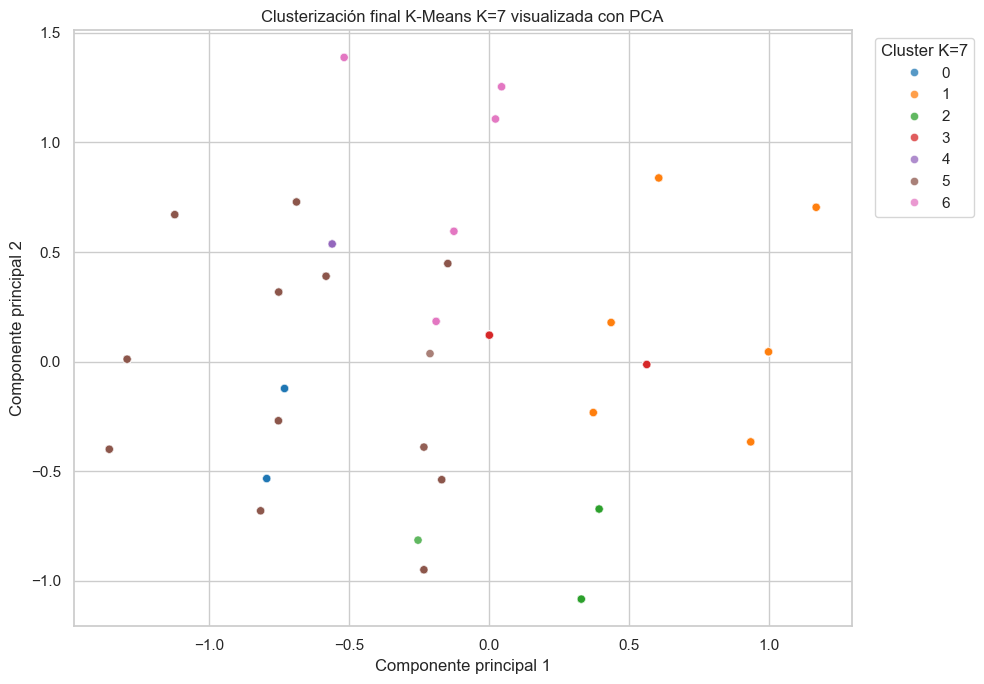

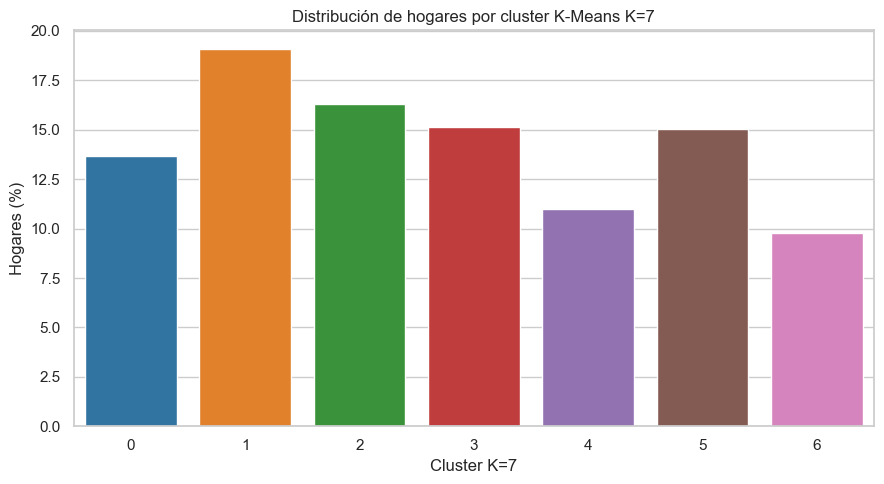

,cluster_kmeans_k7,hogares,pct_hogares
0,0,737,13.6887
1,1,1027,19.0750
2,2,877,16.2890
3,3,815,15.1374
4,4,593,11.0141
5,5,809,15.0260
6,6,526,9.7697


In [42]:
df_12_plot_kmeans_k7 = df_04_pca.copy()
df_12_plot_kmeans_k7["cluster_kmeans_k7"] = labels_kmeans_k7.astype(int)
df_12_plot_kmeans_k7 = df_12_plot_kmeans_k7.merge(
    df_11_kmeans_k7_por_casa[["casa", "Acorn_grouped", "stdorToU"]],
    on="casa",
    how="left"
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_12_plot_kmeans_k7,
    x="PC1",
    y="PC2",
    hue="cluster_kmeans_k7",
    palette="tab10",
    s=35,
    alpha=0.75
)
plt.title("Clusterización final K-Means K=7 visualizada con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster K=7", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "kmeans_k7_clusterizacion_pca.png", dpi=160, bbox_inches="tight")
plt.show()

cluster_dist = (
    df_11_kmeans_k7_por_casa["cluster_kmeans_k7"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_kmeans_k7")
    .reset_index(name="hogares")
)
cluster_dist["pct_hogares"] = cluster_dist["hogares"] / len(df_11_kmeans_k7_por_casa) * 100
cluster_dist.to_csv(TABLES_DIR / "df_12_distribucion_kmeans_k7.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=cluster_dist, x="cluster_kmeans_k7", y="pct_hogares", palette="tab10")
plt.title("Distribución de hogares por cluster K-Means K=7")
plt.xlabel("Cluster K=7")
plt.ylabel("Hogares (%)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "kmeans_k7_distribucion_clusters.png", dpi=160, bbox_inches="tight")
plt.show()

display(cluster_dist)


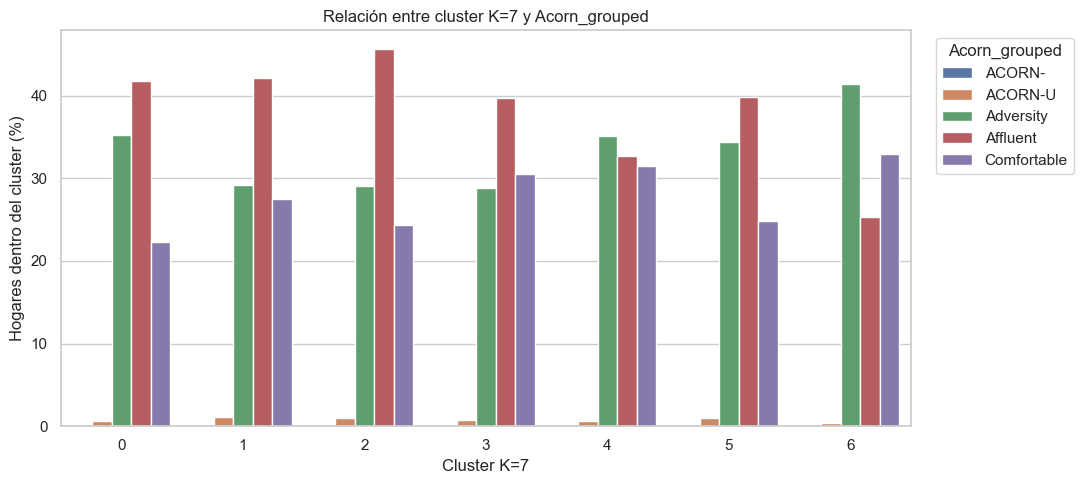

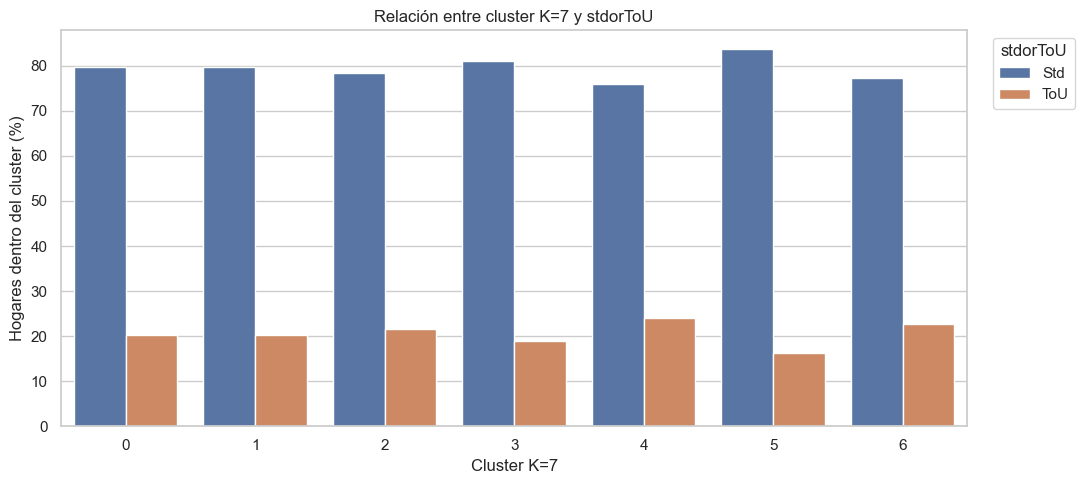

Acorn_grouped,cluster_kmeans_k7,ACORN-,ACORN-U,Adversity,Affluent,Comfortable
0,0,0.0000,0.6800,35.2800,41.7900,22.2500
1,1,0.0000,1.1700,29.2100,42.1600,27.4600
2,2,0.0000,1.0300,29.0800,45.6100,24.2900
3,3,0.1200,0.7400,28.8300,39.7500,30.5500
4,4,0.0000,0.6700,35.0800,32.7200,31.5300
5,5,0.0000,0.9900,34.3600,39.8000,24.8500
6,6,0.0000,0.3800,41.4400,25.2900,32.8900


stdorToU,cluster_kmeans_k7,Std,ToU
0,0,79.6500,20.3500
1,1,79.8400,20.1600
2,2,78.4500,21.5500
3,3,80.9800,19.0200
4,4,75.8900,24.1100
5,5,83.6800,16.3200
6,6,77.3800,22.6200


In [43]:
def graficar_relacion_negocio(df, variable, archivo):
    tabla = pd.crosstab(df["cluster_kmeans_k7"], df[variable], normalize="index") * 100
    tabla = tabla.round(2).reset_index()
    tabla_larga = tabla.melt(id_vars="cluster_kmeans_k7", var_name=variable, value_name="pct_hogares")

    plt.figure(figsize=(11, 5))
    sns.barplot(data=tabla_larga, x="cluster_kmeans_k7", y="pct_hogares", hue=variable)
    plt.title(f"Relación entre cluster K=7 y {variable}")
    plt.xlabel("Cluster K=7")
    plt.ylabel("Hogares dentro del cluster (%)")
    plt.legend(title=variable, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / archivo, dpi=160, bbox_inches="tight")
    plt.show()

    return tabla

df_13_relacion_acorn_k7 = graficar_relacion_negocio(df_11_kmeans_k7_por_casa, "Acorn_grouped", "kmeans_k7_relacion_acorn_grouped.png")
df_13_relacion_tarifa_k7 = graficar_relacion_negocio(df_11_kmeans_k7_por_casa, "stdorToU", "kmeans_k7_relacion_stdorToU.png")

df_13_relacion_acorn_k7.to_csv(TABLES_DIR / "df_13_relacion_kmeans_k7_Acorn_grouped.csv", index=False)
df_13_relacion_tarifa_k7.to_csv(TABLES_DIR / "df_13_relacion_kmeans_k7_stdorToU.csv", index=False)

display(df_13_relacion_acorn_k7)
display(df_13_relacion_tarifa_k7)


# 14. Perfil de clusters K = 7

Finalmente se resume cada cluster con su combinación dominante de consumo, horario, patrón semanal, tipo de consumo, perfil del hogar y tarifa. Esta tabla ayuda a traducir los clusters técnicos en segmentos accionables.


In [44]:
variables_perfil_final = [
    "cluster_consumo",
    "horario_consumo",
    "semanal",
    "tipo_consumo",
    "Acorn_grouped",
    "stdorToU"
]

registros_perfil = []
for cluster, grupo in df_11_kmeans_k7_por_casa.groupby("cluster_kmeans_k7"):
    registro = {
        "cluster_kmeans_k7": cluster,
        "hogares": len(grupo),
        "pct_hogares": len(grupo) / len(df_11_kmeans_k7_por_casa) * 100
    }
    for var in variables_perfil_final:
        moda = grupo[var].mode(dropna=True)
        registro[f"{var}_dominante"] = moda.iloc[0] if len(moda) else np.nan
        registro[f"{var}_dominante_pct"] = grupo[var].value_counts(normalize=True, dropna=True).iloc[0] * 100 if grupo[var].notna().any() else np.nan
    registros_perfil.append(registro)

df_14_perfil_clusters_kmeans_k7 = pd.DataFrame(registros_perfil).sort_values("cluster_kmeans_k7").reset_index(drop=True)
df_14_perfil_clusters_kmeans_k7.to_csv(TABLES_DIR / "df_14_perfil_clusters_kmeans_k7.csv", index=False)

display(df_14_perfil_clusters_kmeans_k7)


,cluster_kmeans_k7,hogares,pct_hogares,cluster_consumo_dominante,cluster_consumo_dominante_pct,horario_consumo_dominante,horario_consumo_dominante_pct,semanal_dominante,semanal_dominante_pct,tipo_consumo_dominante,tipo_consumo_dominante_pct,Acorn_grouped_dominante,Acorn_grouped_dominante_pct,stdorToU_dominante,stdorToU_dominante_pct
0,0,737,13.6887,1,63.7720,consumo_tarde_estable,100.0000,consumo_fin_semana_estable,100.0000,picos_bajos_variabilidad_baja,100.0000,Affluent,41.7910,Std,79.6472
1,1,1027,19.0750,0,51.6066,consumo_noche_variable,100.0000,consumo_fin_semana_variable,100.0000,picos_bajos_variabilidad_baja,97.6631,Affluent,42.1616,Std,79.8442
2,2,877,16.2890,1,67.7309,consumo_noche_variable,99.8860,consumo_fin_semana_estable,100.0000,picos_bajos_variabilidad_baja,100.0000,Affluent,45.6100,Std,78.4493
3,3,815,15.1374,0,100.0000,consumo_noche_variable,100.0000,consumo_fin_semana_estable,100.0000,picos_bajos_variabilidad_baja,96.9325,Affluent,39.7546,Std,80.9816
4,4,593,11.0141,0,100.0000,consumo_tarde_estable,100.0000,consumo_fin_semana_estable,100.0000,picos_bajos_variabilidad_baja,100.0000,Adversity,35.0759,Std,75.8853
5,5,809,15.0260,1,42.6452,consumo_tarde_estable,85.7849,consumo_fin_semana_estable,89.1224,picos_moderados_variabilidad_media,99.7528,Affluent,39.8022,Std,83.6836
6,6,526,9.7697,0,63.1179,consumo_tarde_estable,99.4297,consumo_fin_semana_variable,100.0000,picos_bajos_variabilidad_baja,87.8327,Adversity,41.4449,Std,77.3764


## Tabla de segmentos, descripción y decisiones de negocio

| Cluster | Segmento | Descripción | Acciones recomendadas |
|---:|---|---|---|
| 0 | Hogar eficiente de rutina vespertina | Bajo consumo, uso concentrado en la tarde, comportamiento estable y sin picos. | 1. Enviar reportes comparativos para reforzar hábitos eficientes (benchmark vs hogares similares). <br> 2. Promover programas de fidelización para retener clientes eficientes. <br> 3. Ofrecer recomendaciones de optimización en electrodomésticos de uso vespertino (iluminación, cocina, etc.). |
| 1 | Hogar nocturno con variación en fines de semana | Consumo medio-alto, actividad nocturna y cambios entre semana y fin de semana. | 1. Evaluar migración a tarifa ToU para aprovechar consumo fuera de horas pico. <br> 2. Implementar alertas de consumo en fines de semana para controlar variabilidad. <br> 3. Diseñar campañas de “shift de consumo” para mover carga a horarios más eficientes. |
| 2 | Hogar eficiente nocturno | Bajo consumo, concentrado en la noche y comportamiento estable. | 1. Ofrecer beneficios o descuentos en consumo nocturno (si aplica tarifa ToU). <br> 2. Promover automatización (programación de electrodomésticos nocturnos). <br> 3. Mantener comunicación enfocada en eficiencia sin saturar al cliente. |
| 3 | Hogar nocturno con consumo estable | Consumo medio-alto, nocturno y predecible. | 1. Ofrecer planes de facturación predecible o suscripción energética. <br> 2. Recomendar eficiencia en equipos de uso nocturno (calefacción, entretenimiento). <br> 3. Evaluar transición a tarifa ToU para optimizar costos del cliente y del sistema. |
| 4 | Hogar tradicional de consumo estable | Consumo medio-alto, estable, con mayor presencia en ACORN Adversity. | 1. Implementar programas de educación energética accesibles (sin inversión inicial). <br> 2. Enviar alertas simples de consumo y recomendaciones prácticas de ahorro. <br> 3. Evaluar programas de apoyo o subsidio energético dirigidos. |
| 5 | Hogar eficiente con picos ocasionales | Bajo consumo general con eventos puntuales de alto consumo. | 1. Activar alertas automáticas de picos de consumo. <br> 2. Enviar reportes explicativos (“qué pudo causar el pico”). <br> 3. Recomendar monitoreo de electrodomésticos de alto consumo (lavadora, calefacción, etc.). |
| 6 | Hogar vespertino con actividad en fin de semana | Consumo medio-alto, estable en semana pero variable en fines de semana. | 1. Diseñar recomendaciones específicas para consumo en fin de semana. <br> 2. Promover uso eficiente de electrodomésticos en días de mayor actividad. <br> 3. Evaluar incentivos para redistribuir consumo hacia horarios menos demandados. |

# 15. Inventario actualizado de outputs

Se actualiza el inventario de archivos generados, incluyendo el entrenamiento final K-Means K=7, las asignaciones por casa y las gráficas de interpretación.


In [45]:
archivos_generados = []
for carpeta, tipo in [(TABLES_DIR, "tabla"), (IMAGES_DIR, "grafica")]:
    for archivo in sorted(carpeta.glob("*")):
        archivos_generados.append({
            "tipo": tipo,
            "archivo": archivo.name,
            "ruta": str(archivo.relative_to(PROJECT_DIR))
        })

df_15_archivos_generados = pd.DataFrame(archivos_generados)
df_15_archivos_generados.to_csv(TABLES_DIR / "df_15_archivos_generados.csv", index=False)
display(df_15_archivos_generados)


,tipo,archivo,ruta
0,tabla,df_01_resumen_dataset.csv,output/clustering_conclusiones_finales/tables/...
1,tabla,df_02_distribucion_categorias.csv,output/clustering_conclusiones_finales/tables/...
2,tabla,df_03_diccionario_codificacion.csv,output/clustering_conclusiones_finales/tables/...
3,tabla,df_03_matriz_modelo_one_hot.csv,output/clustering_conclusiones_finales/tables/...
4,tabla,df_04_pca_visualizacion.csv,output/clustering_conclusiones_finales/tables/...
5,tabla,df_04_varianza_pca_visualizacion.csv,output/clustering_conclusiones_finales/tables/...
6,tabla,df_05_kmeans_evaluacion.csv,output/clustering_conclusiones_finales/tables/...
7,tabla,df_06_dbscan_evaluacion.csv,output/clustering_conclusiones_finales/tables/...
8,tabla,df_07_comparacion_modelos.csv,output/clustering_conclusiones_finales/tables/...
9,tabla,df_08_clusterizacion_final_kmeans_dbscan.csv,output/clustering_conclusiones_finales/tables/...


# Insights Descubiertos:

# Hallazgos principales del perfilamiento de consumo

A partir del análisis de los clusters de magnitud, horario, comportamiento semanal y tipo de consumo, se identificaron cuatro hallazgos principales que permiten entender mejor el comportamiento de los hogares y orientar futuras decisiones de negocio.

---

## 1. La mayoría de los hogares presenta un consumo estable y con picos bajos

### Explicación

Uno de los hallazgos más importantes es que la mayor parte de los hogares no presenta patrones extremos de consumo. En el perfilamiento por tipo de consumo, el grupo dominante corresponde a usuarios con **picos bajos y variabilidad baja**, concentrando aproximadamente el **82.88% de los hogares**.

Este resultado indica que la mayoría de los clientes mantiene un comportamiento relativamente constante en su consumo eléctrico diario. Aunque pueden existir diferencias en el horario en que consumen o en el nivel total de consumo, su patrón general no muestra cambios bruscos ni picos elevados de forma recurrente.

Esto es relevante porque sugiere que el consumo residencial analizado no está dominado por comportamientos caóticos, sino por patrones relativamente predecibles.

### Justificación del hallazgo

Este hallazgo se sostiene principalmente por los resultados del perfilamiento por tipo de consumo:

- El cluster de **picos bajos y variabilidad baja** concentra **4,608 hogares**, equivalente al **82.88%** de la muestra.
- Este grupo presenta un `cv_diario` promedio de **0.3670**, el menor entre los clusters de tipo de consumo.
- También presenta el menor `ratio_pico_intradia`, con un valor de **1.8853**, lo que indica que sus picos de consumo no son excesivamente altos respecto al consumo promedio.

Por lo tanto, existe evidencia suficiente para afirmar que la mayoría de los hogares tiene un comportamiento estable, con baja presencia de picos intensos.

---

## 2. El consumo residencial se concentra principalmente entre la tarde y la noche

### Explicación

El segundo hallazgo es que el consumo de los hogares se concentra principalmente en horarios de tarde y noche. En el perfilamiento horario, los dos grupos principales corresponden a hogares con consumo nocturno variable y hogares con consumo tarde/diurno estable.

El grupo más grande concentra su mayor porcentaje de consumo durante la noche, mientras que el segundo grupo presenta una distribución más equilibrada entre mañana, tarde y noche, aunque con una participación importante en la tarde.

Este comportamiento es consistente con una dinámica residencial: durante el día muchas personas pueden estar fuera del hogar, mientras que en la tarde y noche aumenta el uso de iluminación, electrodomésticos, cocina, entretenimiento, calefacción u otros equipos eléctricos.

### Justificación del hallazgo

Este hallazgo se defiende con base en la segmentación por horario:

- El cluster de **consumo nocturno variable** representa **2,864 hogares**, equivalente al **51.51%** de la muestra.
- En este grupo, el consumo nocturno representa **38.17%** del consumo total diario.
- El segundo cluster, identificado como **consumo tarde estable**, representa **2,621 hogares**, equivalente al **47.14%** de la muestra.
- En este grupo, el consumo de tarde representa **29.87%** y el consumo de noche **29.66%**, valores muy cercanos y superiores al consumo de madrugada.

En conjunto, estos dos clusters representan más del **98% de los hogares**, lo que permite concluir que el consumo residencial se concentra principalmente entre tarde y noche.

---

## 3. Los hogares de alto consumo tienen un impacto energético desproporcionado

### Explicación

El tercer hallazgo es que los hogares de consumo alto, aunque no necesariamente sean mayoría, tienen un impacto muy superior sobre la demanda energética total.

El cluster de consumo alto o intensivo presenta un consumo medio promedio de **21.26**, mientras que el cluster de consumo bajo presenta un consumo medio promedio de **4.38**. Esto significa que un hogar de consumo alto consume aproximadamente **4.85 veces** lo que consume un hogar de bajo consumo.

Este hallazgo es especialmente importante para la toma de decisiones, porque muestra que no todos los hogares tienen el mismo peso operativo. Una reducción pequeña en el consumo de los hogares intensivos puede tener mayor impacto que intervenir muchos hogares de bajo consumo.

### Justificación del hallazgo

La defensa se basa en la comparación directa entre los clusters de magnitud de consumo:

- Cluster de consumo bajo:
  - Consumo medio promedio: **4.38**
  - Consumo máximo promedio: **12.14**

- Cluster de consumo alto/intensivo:
  - Consumo medio promedio: **21.26**
  - Consumo máximo promedio: **58.37**

Al comparar ambos consumos medios:

21.26 / 4.38 = 4.

## 4. La estacionalidad de invierno es un factor clave en el consumo, especialmente en hogares de mayor intensidad
### Explicación

El cuarto hallazgo es que el consumo durante invierno es superior al consumo durante verano en los grupos de consumo medio-alto y alto. Esto sugiere que existe una sensibilidad estacional relevante, posiblemente asociada a condiciones climáticas, mayor uso de calefacción, iluminación o mayor permanencia en el hogar durante meses fríos.

Este hallazgo es importante porque permite identificar que el riesgo de mayor demanda no se distribuye igual durante todo el año. En particular, los hogares de consumo alto muestran una diferencia considerable entre invierno y verano, lo que puede convertirlos en un segmento prioritario durante temporadas frías.

Sin embargo, es importante aclarar que el análisis permite identificar una relación estacional, pero no permite confirmar por sí solo la causa exacta del incremento. Para afirmar que se debe a calefacción u otro uso específico, sería necesario contar con variables adicionales.

### Justificación del hallazgo

El hallazgo se sostiene con los resultados de magnitud de consumo:

Cluster de consumo medio-alto estable:
Consumo invierno promedio: 11.17
Consumo verano promedio: 8.73
Diferencia aproximada: 2.44
Cluster de consumo alto/intensivo:
Consumo invierno promedio: 27.34
Consumo verano promedio: 14.85
Diferencia aproximada: 12.49

En el cluster alto, el consumo de invierno es aproximadamente:

27.34 / 14.85 = 1.84

Es decir, el consumo promedio de invierno es cerca de 84% mayor que el consumo promedio de verano.

Esto demuestra que la estacionalidad es especialmente fuerte en el grupo de consumo intensivo, por lo que debe considerarse como una variable relevante para el diseño de estrategias de reducción de demanda, tarifas diferenciadas o campañas de eficiencia energética.

# Perfilamiento de clusters

# Perfilamiento detallado de clusters por variables de comportamiento

A partir del modelo K-Means con K=7, se construyó un perfilamiento final combinando magnitud de consumo, horario dominante, comportamiento semanal, tipo de consumo, perfil socioeconómico y tipo de tarifa. Para hacer la interpretación más clara para negocio, se ajustaron algunas etiquetas:

- `medio-alto` se interpreta como **alto**.
- `noche_variable` se interpreta como **nocturno**.
- `picos_bajos_variabilidad_baja` se interpreta como **picos bajos / consumo estable**.
- `picos_moderados_variabilidad_media` se interpreta como **picos moderados / variabilidad media**.

---

## Cluster 0: Hogares eficientes de consumo diurno estable

| Elemento | Descripción |
|---|---|
| Cluster | 0 |
| Hogares | 737 |
| Porcentaje de hogares | 13.69% |
| Consumo dominante | Bajo |
| Consumo dominante dentro del cluster | 63.77% |
| Horario dominante | Tarde estable |
| Horario dominante dentro del cluster | 100.00% |
| Comportamiento semanal | Fin de semana estable |
| Comportamiento semanal dentro del cluster | 100.00% |
| Tipo de consumo | Picos bajos / consumo estable |
| Tipo de consumo dentro del cluster | 100.00% |
| Perfil socioeconómico dominante | Affluent |
| Perfil socioeconómico dentro del cluster | 41.79% |
| Tarifa dominante | Std |
| Tarifa dominante dentro del cluster | 79.65% |
| Nombre de negocio | Hogares eficientes de consumo diurno estable |

### Perfilamiento del hogar

Este cluster representa hogares con **bajo consumo eléctrico** y un comportamiento bastante regular. Su consumo se concentra principalmente durante la tarde, sin cambios importantes durante el fin de semana y sin presencia de picos relevantes.

Este perfil puede explicarse por hogares con rutinas ordenadas, menor número de habitantes o buena eficiencia energética. También podrían ser personas que pasan buena parte del día fuera de casa y utilizan electricidad principalmente al regresar por la tarde para actividades básicas como cocinar, iluminar el hogar, lavar, usar dispositivos electrónicos o descansar.

### Lectura de negocio

Este grupo no parece representar un problema operativo importante para la empresa, ya que consume poco y de forma estable. Su valor está más relacionado con **fidelización, comunicación preventiva y mantenimiento de satisfacción**, no necesariamente con campañas agresivas de reducción de consumo.

---

## Cluster 1: Hogares de alto consumo nocturno con actividad variable en fin de semana

| Elemento | Descripción |
|---|---|
| Cluster | 1 |
| Hogares | 1,027 |
| Porcentaje de hogares | 19.08% |
| Consumo dominante | Alto |
| Consumo dominante dentro del cluster | 51.61% |
| Horario dominante | Nocturno |
| Horario dominante dentro del cluster | 100.00% |
| Comportamiento semanal | Fin de semana variable |
| Comportamiento semanal dentro del cluster | 100.00% |
| Tipo de consumo | Picos bajos / consumo estable |
| Tipo de consumo dentro del cluster | 97.66% |
| Perfil socioeconómico dominante | Affluent |
| Perfil socioeconómico dentro del cluster | 42.16% |
| Tarifa dominante | Std |
| Tarifa dominante dentro del cluster | 79.84% |
| Nombre de negocio | Hogares de alto consumo nocturno con actividad variable en fin de semana |

### Perfilamiento del hogar

Este cluster agrupa hogares con **consumo alto**, concentrado principalmente durante la noche, y con cambios relevantes durante el fin de semana. Aunque su tipo de consumo dominante sigue siendo estable y con picos bajos, el patrón semanal indica que sábado y domingo modifican el comportamiento habitual del hogar.

Este perfil puede explicarse por familias o personas que trabajan fuera de casa durante el día y concentran su consumo eléctrico al regresar por la noche. Durante el fin de semana, el consumo puede aumentar por mayor permanencia en el hogar, uso de electrodomésticos, cocina, lavado, entretenimiento, calefacción, reuniones familiares o actividades domésticas acumuladas.

### Lectura de negocio

Este es uno de los clusters más relevantes porque combina **alto consumo, horario nocturno y variación de fin de semana**. No necesariamente es un segmento problemático, pero sí puede generar presión sobre la demanda en momentos específicos. Es un grupo candidato para estrategias de eficiencia energética, recomendaciones personalizadas y evaluación de tarifas diferenciadas.

---

## Cluster 2: Hogares de bajo consumo nocturno estable

| Elemento | Descripción |
|---|---|
| Cluster | 2 |
| Hogares | 877 |
| Porcentaje de hogares | 16.29% |
| Consumo dominante | Bajo |
| Consumo dominante dentro del cluster | 67.73% |
| Horario dominante | Nocturno |
| Horario dominante dentro del cluster | 99.89% |
| Comportamiento semanal | Fin de semana estable |
| Comportamiento semanal dentro del cluster | 100.00% |
| Tipo de consumo | Picos bajos / consumo estable |
| Tipo de consumo dentro del cluster | 100.00% |
| Perfil socioeconómico dominante | Affluent |
| Perfil socioeconómico dentro del cluster | 45.61% |
| Tarifa dominante | Std |
| Tarifa dominante dentro del cluster | 78.45% |
| Nombre de negocio | Hogares de bajo consumo nocturno estable |

### Perfilamiento del hogar

Este grupo representa hogares de **bajo consumo eléctrico** que concentran su actividad principalmente durante la noche. A diferencia del cluster 1, aquí el consumo es bajo y el comportamiento semanal es estable, por lo que no se observan cambios fuertes entre días laborales y fines de semana.

Puede tratarse de hogares pequeños, personas que trabajan o estudian durante el día, parejas jóvenes o viviendas con baja ocupación durante gran parte de la jornada. Su consumo nocturno puede estar asociado a actividades básicas como iluminación, cocina ligera, televisión, carga de dispositivos, uso de computadora, refrigeración y descanso.

### Lectura de negocio

Este cluster no debería ser prioridad para campañas de reducción energética, ya que su consumo es bajo y estable. Sin embargo, puede ser útil para **comunicación personalizada**, fidelización o venta de servicios adicionales de bajo impacto, como herramientas de monitoreo, planes digitales o recomendaciones de eficiencia simples.

---

## Cluster 3: Hogares de alto consumo nocturno estable

| Elemento | Descripción |
|---|---|
| Cluster | 3 |
| Hogares | 815 |
| Porcentaje de hogares | 15.14% |
| Consumo dominante | Alto |
| Consumo dominante dentro del cluster | 100.00% |
| Horario dominante | Nocturno |
| Horario dominante dentro del cluster | 100.00% |
| Comportamiento semanal | Fin de semana estable |
| Comportamiento semanal dentro del cluster | 100.00% |
| Tipo de consumo | Picos bajos / consumo estable |
| Tipo de consumo dentro del cluster | 96.93% |
| Perfil socioeconómico dominante | Affluent |
| Perfil socioeconómico dentro del cluster | 39.75% |
| Tarifa dominante | Std |
| Tarifa dominante dentro del cluster | 80.98% |
| Nombre de negocio | Hogares de alto consumo nocturno estable |

### Perfilamiento del hogar

Este cluster representa hogares con **alto consumo eléctrico constante**, concentrado principalmente durante la noche. A diferencia del cluster 1, aquí el comportamiento semanal es estable, por lo que el consumo elevado no depende tanto del fin de semana, sino que parece formar parte de una rutina diaria.

Este perfil puede explicarse por hogares con varios habitantes, mayor uso de calefacción, iluminación, entretenimiento, cocina, electrodomésticos o equipos eléctricos durante la noche. También podría representar viviendas donde la mayor parte de la actividad ocurre después de la jornada laboral o escolar.

### Lectura de negocio

Este es probablemente uno de los clusters más importantes para el negocio, porque combina **alto consumo y estabilidad**. Al ser un patrón constante, es más fácil de identificar, monitorear e intervenir. Una mejora pequeña en este grupo podría generar un impacto relevante en la reducción de demanda total.

---

## Cluster 4: Hogares vulnerables de alto consumo estable por la tarde

| Elemento | Descripción |
|---|---|
| Cluster | 4 |
| Hogares | 593 |
| Porcentaje de hogares | 11.01% |
| Consumo dominante | Alto |
| Consumo dominante dentro del cluster | 100.00% |
| Horario dominante | Tarde estable |
| Horario dominante dentro del cluster | 100.00% |
| Comportamiento semanal | Fin de semana estable |
| Comportamiento semanal dentro del cluster | 100.00% |
| Tipo de consumo | Picos bajos / consumo estable |
| Tipo de consumo dentro del cluster | 100.00% |
| Perfil socioeconómico dominante | Adversity |
| Perfil socioeconómico dentro del cluster | 35.08% |
| Tarifa dominante | Std |
| Tarifa dominante dentro del cluster | 75.89% |
| Nombre de negocio | Hogares vulnerables de alto consumo estable por la tarde |

### Perfilamiento del hogar

Este cluster agrupa hogares con **alto consumo eléctrico**, comportamiento estable y mayor actividad durante la tarde. Además, el perfil socioeconómico dominante es **Adversity**, lo que sugiere hogares con posibles limitaciones económicas o condiciones de vivienda menos favorables.

Este patrón puede explicarse por familias con varios integrantes, mayor permanencia en casa durante la tarde, viviendas con menor eficiencia energética, uso intensivo de electrodomésticos básicos o dependencia de equipos eléctricos para actividades cotidianas. El consumo alto no necesariamente implica lujo o desperdicio; puede estar relacionado con necesidad, tamaño del hogar o baja eficiencia de la vivienda.

### Lectura de negocio

Este cluster debe tratarse con cuidado. Aunque tiene alto consumo, no conviene abordarlo únicamente desde una lógica comercial o de penalización. Es un grupo relevante para programas de eficiencia energética, apoyo al cliente, educación de consumo y posibles esquemas sociales. Una mala estrategia aquí podría generar riesgo reputacional o afectar a clientes vulnerables.

---

## Cluster 5: Hogares con picos moderados de consumo diurno

| Elemento | Descripción |
|---|---|
| Cluster | 5 |
| Hogares | 809 |
| Porcentaje de hogares | 15.03% |
| Consumo dominante | Bajo / mixto |
| Consumo dominante dentro del cluster | 42.65% |
| Horario dominante | Tarde estable |
| Horario dominante dentro del cluster | 85.78% |
| Comportamiento semanal | Fin de semana estable |
| Comportamiento semanal dentro del cluster | 89.12% |
| Tipo de consumo | Picos moderados / variabilidad media |
| Tipo de consumo dentro del cluster | 99.75% |
| Perfil socioeconómico dominante | Affluent |
| Perfil socioeconómico dentro del cluster | 39.80% |
| Tarifa dominante | Std |
| Tarifa dominante dentro del cluster | 83.68% |
| Nombre de negocio | Hogares con picos moderados de consumo diurno |

### Perfilamiento del hogar

Este cluster es distinto a los demás porque no se define principalmente por la magnitud del consumo, sino por la **forma del consumo**. Aunque el consumo dominante aparece como bajo o mixto, casi todo el grupo presenta picos moderados y variabilidad media.

Esto puede explicarse por hogares que tienen momentos específicos de uso intensivo durante el día o la tarde. Por ejemplo, uso concentrado de lavadora, secadora, cocina eléctrica, calefacción, aire acondicionado, home office, carga de dispositivos, herramientas domésticas o actividades familiares en horarios determinados.

### Lectura de negocio

Este cluster es importante para estrategias de manejo de picos. Aunque no todos sean grandes consumidores, su patrón puede generar concentración de demanda en ciertos momentos. Es un buen grupo para recomendaciones de desplazamiento de carga, automatización de consumo y educación sobre horarios de uso.

---

## Cluster 6: Hogares vulnerables de alto consumo con variación de fin de semana

| Elemento | Descripción |
|---|---|
| Cluster | 6 |
| Hogares | 526 |
| Porcentaje de hogares | 9.77% |
| Consumo dominante | Alto |
| Consumo dominante dentro del cluster | 63.12% |
| Horario dominante | Tarde estable |
| Horario dominante dentro del cluster | 99.43% |
| Comportamiento semanal | Fin de semana variable |
| Comportamiento semanal dentro del cluster | 100.00% |
| Tipo de consumo | Picos bajos / consumo estable |
| Tipo de consumo dentro del cluster | 87.83% |
| Perfil socioeconómico dominante | Adversity |
| Perfil socioeconómico dentro del cluster | 41.44% |
| Tarifa dominante | Std |
| Tarifa dominante dentro del cluster | 77.38% |
| Nombre de negocio | Hogares vulnerables de alto consumo con variación de fin de semana |

### Perfilamiento del hogar

Este cluster representa hogares con **alto consumo eléctrico**, actividad principalmente durante la tarde y cambios importantes durante el fin de semana. Además, el perfil socioeconómico dominante es **Adversity**, lo que indica que puede tratarse de hogares con mayor sensibilidad económica.

Este comportamiento puede explicarse por familias que concentran actividades domésticas durante sábado y domingo, como lavado, limpieza, cocina, convivencia familiar o uso prolongado de aparatos eléctricos. También puede relacionarse con viviendas de menor eficiencia energética, mayor número de habitantes o hábitos de consumo acumulados durante el fin de semana.

### Lectura de negocio

Este cluster es relevante porque combina consumo alto, variabilidad semanal y vulnerabilidad socioeconómica. Las acciones deben enfocarse en eficiencia y acompañamiento, no en penalización. Puede ser un grupo prioritario para campañas de ahorro, asesoría personalizada, programas sociales o incentivos para reducir consumo sin afectar la calidad de vida del hogar.

---

# Comparación general de clusters

| Cluster | Nombre de negocio | Prioridad para negocio | Razón principal |
|---:|---|---|---|
| 0 | Hogares eficientes de consumo diurno estable | Baja | Bajo consumo y comportamiento estable |
| 1 | Hogares de alto consumo nocturno con actividad variable en fin de semana | Alta | Alto consumo, horario nocturno y variación semanal |
| 2 | Hogares de bajo consumo nocturno estable | Baja | Bajo consumo y estabilidad |
| 3 | Hogares de alto consumo nocturno estable | Alta | Alto consumo constante y fácil de monitorear |
| 4 | Hogares vulnerables de alto consumo estable por la tarde | Alta social | Alto consumo con perfil socioeconómico vulnerable |
| 5 | Hogares con picos moderados de consumo diurno | Media-alta | Presencia clara de picos moderados |
| 6 | Hogares vulnerables de alto consumo con variación de fin de semana | Alta social | Alto consumo, fin de semana variable y vulnerabilidad |

---

# Conclusión

El modelo K=7 permite identificar segmentos más detallados que una clasificación simple de consumo bajo o alto. Los clusters no solo indican cuánto consume un hogar, sino también cuándo consume, qué tan estable es su patrón, si cambia durante el fin de semana, qué tipo de picos presenta y qué perfil socioeconómico domina.

Esta segmentación permite separar los hogares en grupos más útiles para negocio:

- Hogares de bajo consumo que requieren poco nivel de intervención.
- Hogares de alto consumo que pueden generar mayor impacto operativo.
- Hogares vulnerables que requieren estrategias cuidadosas.
- Hogares con picos moderados que pueden beneficiarse de acciones de gestión de demanda.

# Propuesta de campañas

# Campañas de negocio basadas en los clusters K=7

A partir del perfilamiento de los clusters K=7, se proponen campañas orientadas a eficiencia energética, reducción de demanda, fidelización, educación de consumo y protección de hogares vulnerables. Estas campañas buscan convertir la segmentación analítica en acciones medibles para el negocio.

---

## Campaña 1: Reducción de consumo nocturno en hogares de alto consumo

| Elemento | Descripción |
|---|---|
| Nombre de campaña | Consumo nocturno inteligente |
| Clusters objetivo | Cluster 1 y Cluster 3 |
| Perfil objetivo | Hogares de alto consumo con actividad principalmente nocturna |
| Problema detectado | Estos hogares concentran un consumo elevado durante la noche, lo que puede incrementar la demanda en horarios específicos. |
| Objetivo de negocio | Reducir el consumo nocturno en hogares de alto consumo sin afectar su calidad de vida. |
| Acción principal | Enviar recomendaciones personalizadas para mover ciertos consumos a horarios de menor demanda, como lavado, carga de dispositivos, uso de electrodomésticos o calefacción programable. |
| Incentivo posible | Bonificación si reducen cierto porcentaje del consumo nocturno durante el mes |
| KPI principal | Reducción porcentual del consumo nocturno promedio |
| Meta medible | Reducir entre 5% y 8% el consumo nocturno promedio en los clusters 1 y 3 durante 3 meses |

### Justificación

Los clusters 1 y 3 tienen consumo alto y comportamiento nocturno. El cluster 3 es especialmente relevante porque el 100% de sus hogares tiene consumo alto dominante y consumo nocturno. Esto lo convierte en un segmento claro para reducir demanda sin tener que intervenir a toda la base de clientes.

---

## Campaña 2: Programa de eficiencia energética para hogares vulnerables de alto consumo

| Elemento | Descripción |
|---|---|
| Nombre de campaña | Energía eficiente para hogares vulnerables |
| Clusters objetivo | Cluster 4 y Cluster 6 |
| Perfil objetivo | Hogares de alto consumo con perfil socioeconómico dominante Adversity |
| Problema detectado | Estos hogares tienen alto consumo, pero pueden tener menor capacidad económica para absorber incrementos en su factura. |
| Objetivo de negocio | Reducir el consumo de hogares vulnerables mediante apoyo, educación y eficiencia energética de bajo costo. |
| Acción principal | Ofrecer diagnósticos de consumo, consejos personalizados, kits de ahorro energético o recomendaciones para reducir gasto sin penalizar al usuario. |
| Incentivo posible | Kit gratuito o descuento por reducción sostenida de consumo |
| KPI principal | Reducción del consumo promedio mensual |
| Meta medible | Reducir entre 4% y 6% el consumo promedio mensual en clusters 4 y 6 en un periodo de 4 meses |
| Meta secundaria | Reducir 10% los reclamos asociados a consumo alto en estos segmentos |

### Justificación

Los clusters 4 y 6 combinan dos elementos sensibles: **alto consumo** y perfil **Adversity**. Por eso, no conviene diseñar campañas de penalización. La estrategia debe enfocarse en acompañamiento, eficiencia y prevención de facturas elevadas.

---

## Campaña 3: Gestión de picos moderados de consumo

| Elemento | Descripción |
|---|---|
| Nombre de campaña | Evita tus picos de consumo |
| Clusters objetivo | Cluster 5 |
| Perfil objetivo | Hogares con picos moderados y variabilidad media |
| Problema detectado | Este grupo no se define tanto por consumir mucho, sino por concentrar consumo en ciertos momentos del día. |
| Objetivo de negocio | Reducir la concentración de demanda en horarios específicos. |
| Acción principal | Enviar alertas cuando el consumo del hogar se acerque a su patrón de pico habitual y recomendar distribuir actividades eléctricas. |
| Incentivo posible | Reconocimiento o descuento si el hogar reduce sus picos durante varios ciclos |
| KPI principal | Reducción del ratio de pico intradía |
| Meta medible | Reducir 7% el ratio de pico intradía promedio del cluster 5 en 3 meses |
| Meta secundaria | Reducir 5% el consumo máximo diario promedio en hogares participantes |

### Justificación

El cluster 5 es el más diferente por forma de consumo, ya que casi todo el grupo presenta picos moderados y variabilidad media. La oportunidad no está necesariamente en reducir todo el consumo, sino en suavizar los picos.

---

## Campaña 4: Migración inteligente a tarifa ToU

| Elemento | Descripción |
|---|---|
| Nombre de campaña | Tarifa inteligente según tu horario |
| Clusters objetivo | Cluster 1, Cluster 3 y Cluster 5 |
| Perfil objetivo | Hogares con consumo alto, nocturno o con picos moderados |
| Problema detectado | La tarifa dominante en todos los clusters es Std, aunque algunos patrones podrían beneficiarse de tarifas diferenciadas por horario. |
| Objetivo de negocio | Identificar clientes con potencial de migrar a tarifa ToU y medir si la tarifa mejora eficiencia o reduce demanda en horarios críticos. |
| Acción principal | Simular cuánto habrían pagado los hogares con una tarifa ToU y ofrecer migración solo a quienes tengan potencial de beneficio o reducción de demanda. |
| Incentivo posible | Prueba piloto de tarifa ToU durante 2 o 3 meses |
| KPI principal | Tasa de migración voluntaria a ToU |
| Meta medible | Migrar al menos 10% de los hogares elegibles de clusters 1, 3 y 5 a una prueba ToU |
| Meta secundaria | Reducir 5% el consumo en horario crítico entre los hogares migrados |

### Justificación

La mayoría de los hogares permanece en tarifa Std. Sin embargo, clusters con consumo nocturno, variación semanal o picos moderados podrían responder bien a señales de precio. Esta campaña debe hacerse con simulación previa para evitar ofrecer ToU a clientes que podrían terminar pagando más sin entender por qué.

---

## Campaña 5: Campaña de fin de semana eficiente

| Elemento | Descripción |
|---|---|
| Nombre de campaña | Fin de semana eficiente |
| Clusters objetivo | Cluster 1 y Cluster 6 |
| Perfil objetivo | Hogares con consumo variable durante sábado y domingo |
| Problema detectado | Estos hogares modifican su patrón de consumo durante el fin de semana. |
| Objetivo de negocio | Reducir el incremento de consumo asociado a fines de semana. |
| Acción principal | Enviar recomendaciones específicas los viernes para distribuir actividades como lavado, cocina, limpieza, calefacción o entretenimiento intensivo. |
| Incentivo posible | Bonificación mensual si el hogar mantiene su consumo de fin de semana dentro de un rango objetivo |
| KPI principal | Reducción del consumo promedio de fin de semana |
| Meta medible | Reducir 5% el consumo promedio de sábado y domingo en clusters 1 y 6 durante 3 meses |
| Meta secundaria | Reducir 4% el ratio fin de semana vs semana en hogares participantes |

### Justificación

Los clusters 1 y 6 tienen comportamiento de fin de semana variable. Esto significa que sábado y domingo alteran su patrón normal de consumo. Una campaña específica por día puede ser más efectiva que una campaña general de ahorro.

---

## Campaña 6: Fidelización de hogares eficientes

| Elemento | Descripción |
|---|---|
| Nombre de campaña | Hogar eficiente reconocido |
| Clusters objetivo | Cluster 0 y Cluster 2 |
| Perfil objetivo | Hogares de bajo consumo y comportamiento estable |
| Problema detectado | Estos hogares ya consumen poco, por lo que no requieren intervención fuerte, pero sí pueden ser retenidos y fidelizados. |
| Objetivo de negocio | Aumentar satisfacción y permanencia de clientes eficientes. |
| Acción principal | Reconocer a los hogares con consumo eficiente mediante mensajes comparativos, insignias digitales o beneficios pequeños. |
| Incentivo posible | Reconocimiento mensual, puntos, descuentos en servicios digitales o recomendaciones premium |
| KPI principal | Tasa de retención o permanencia |
| Meta medible | Incrementar 3% la retención de clientes en clusters 0 y 2 durante 6 meses |
| Meta secundaria | Lograr 35% de apertura en mensajes personalizados de eficiencia |

### Justificación

Los clusters 0 y 2 no son prioritarios para reducción de demanda, porque ya tienen bajo consumo. Pero sí pueden ser útiles para estrategias de fidelización, reputación y adopción de servicios digitales.

---

## Campaña 7: Detección y revisión de consumos atípicos

| Elemento | Descripción |
|---|---|
| Nombre de campaña | Revisión inteligente de consumos atípicos |
| Clusters objetivo | Casos atípicos detectados en segmentación semanal y tipo de consumo |
| Perfil objetivo | Hogares con variabilidad extrema o máximos diarios anómalos |
| Problema detectado | Algunos registros muestran valores extremos, como `cv_diario = 16.8876` y `max_diario_vs_promedio = 400.7445`, pero representan muy pocos hogares. |
| Objetivo de negocio | Identificar errores de medición, posibles fraudes, fallas de medidor o consumos extraordinarios. |
| Acción principal | Crear una lista de revisión para hogares con máximos diarios extremos y validar lectura, medidor y patrón histórico. |
| Incentivo posible | No aplica como campaña comercial; es una campaña operativa |
| KPI principal | Porcentaje de casos atípicos revisados |
| Meta medible | Revisar el 100% de casos extremos detectados en el primer mes |
| Meta secundaria | Clasificar al menos 90% de los casos como error, fraude, consumo extraordinario o patrón válido |

### Justificación

Los casos atípicos no deben tratarse como segmento comercial normal. Su tamaño es muy bajo, pero su comportamiento extremo puede distorsionar el análisis o representar riesgos operativos.

---

# Resumen ejecutivo de campañas

| Campaña | Clusters objetivo | Objetivo principal | KPI principal | Meta sugerida |
|---|---|---|---|---|
| Consumo nocturno inteligente | 1 y 3 | Reducir consumo nocturno alto | Consumo nocturno promedio | -5% a -8% en 3 meses |
| Energía eficiente para hogares vulnerables | 4 y 6 | Reducir consumo sin penalizar hogares sensibles | Consumo mensual promedio | -4% a -6% en 4 meses |
| Evita tus picos de consumo | 5 | Reducir picos moderados | Ratio de pico intradía | -7% en 3 meses |
| Tarifa inteligente según tu horario | 1, 3 y 5 | Migrar clientes elegibles a ToU | Tasa de migración | 10% de elegibles |
| Fin de semana eficiente | 1 y 6 | Reducir consumo de sábado y domingo | Consumo promedio de fin de semana | -5% en 3 meses |
| Hogar eficiente reconocido | 0 y 2 | Fidelizar clientes de bajo consumo | Retención / engagement | +3% retención en 6 meses |
| Revisión inteligente de consumos atípicos | Casos extremos | Validar anomalías | Casos revisados | 100% en 1 mes |

---

# Priorización recomendada

| Prioridad | Campaña | Razón |
|---:|---|---|
| 1 | Consumo nocturno inteligente | Ataca clusters de alto consumo y horario dominante |
| 2 | Energía eficiente para hogares vulnerables | Alto impacto social y operativo |
| 3 | Evita tus picos de consumo | Reduce presión operativa sin requerir bajar todo el consumo |
| 4 | Fin de semana eficiente | Campaña sencilla y bien segmentada |
| 5 | Tarifa inteligente según tu horario | Alto valor, pero requiere simulación antes de aplicar |
| 6 | Hogar eficiente reconocido | Más útil para fidelización que para ahorro energético |
| 7 | Revisión inteligente de consumos atípicos | Necesaria para calidad de datos y control operativo |